Exercise 4.3

Code that solves the 1-d linear advection equation $$a_t + ua_x = 0$$ using a simple first-order accurate discretization,

$$\frac{a_i^{n+1} - a_i^n}{\Delta t} = -u\frac{a_i^{n} - a_{i-1}^n}{\Delta x},$$

on the domain [0,1] with $u = 1$ and periodic BC.

Top-hat IC:

$$
a_0 = 
\begin{cases}
0, & \quad x < 1/3, \\
1, & \quad 1/3 \le x < 2/3 \\
0, & \quad 2/3 \le x
\end{cases}
$$

Gaussian IC:
$$
a_0 = e^{-0.5 ((x - \mu)/\sigma)^2}
$$

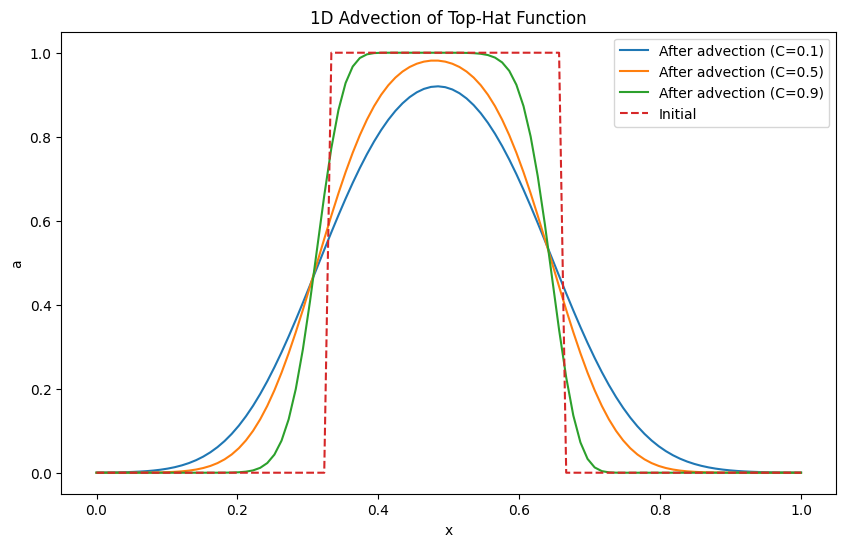

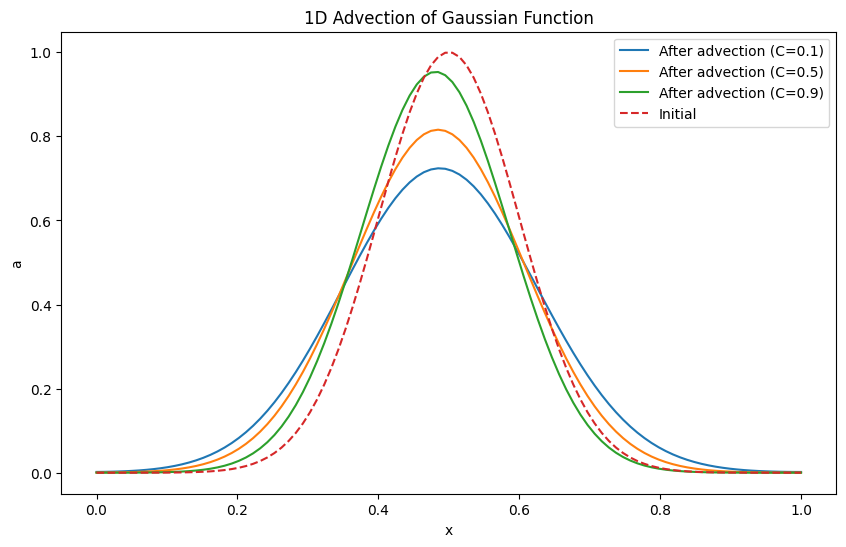

In [38]:
import numpy as np
import matplotlib.pyplot as plt

u = 1.0 # advection speed
nx = 100 # number of spatial points
x = np.linspace(0, 1, nx) # spatial grid [0,1]
dx = x[1] - x[0] # spatial step

def top_hat_IC(x):
    if 0 <= x < 1/3:
        return 0.0
    elif 1/3 <= x < 2/3:
        return 1.0
    else:
        return 0.0
    
def Gaussian_IC(x, mu=0.5, sigma=0.1):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)


x1 = np.arange(nx) # spatial indices

# a_i^n+1 = a_i^n - C*(a_i^n - a_i-1^n)
def upwind(a):
    a_new = np.zeros_like(a)
    for i in range(len(a)):
        a_new[i] = a[i] - C*(a[i] - a[i-1]) # periodic BC: a[-1] = a[nx-1]
    return a_new

#initial condition vector (top-hat function)
x0_top_hat = np.array([top_hat_IC(xi) for xi in x])

#initial condition vector (Gaussian function)
x0_gaussian = np.array([Gaussian_IC(xi) for xi in x])

T = 1 # number of time periods since T = 1/u = 1
for IC, label in zip([x0_top_hat, x0_gaussian], ['Top-Hat', 'Gaussian']):
    plt.figure(figsize=(10, 6))
    for C in [0.1, 0.5, 0.9]: # test different Courant numbers
        dt = C*dx/u # time step
        a = IC.copy()
        for n in range(int(T/dt)):
            a = upwind(a)

        plt.plot(x, a, label=f'After advection (C={C})')    

    plt.plot(x, IC, '--', label='Initial')
    plt.xlabel('x')
    plt.ylabel('a')
    plt.title(f'1D Advection of {label} Function')
    plt.legend()
    plt.show()

Exercise 4.4

Try using a centered-difference for the spatial derivative $$a_x \approx (a_{i+1} - a_{i-1})/(2 \Delta x).$$

You may think it is more accurate, but it is not necessarily. This is called FTCS (forward-time, centered-space).

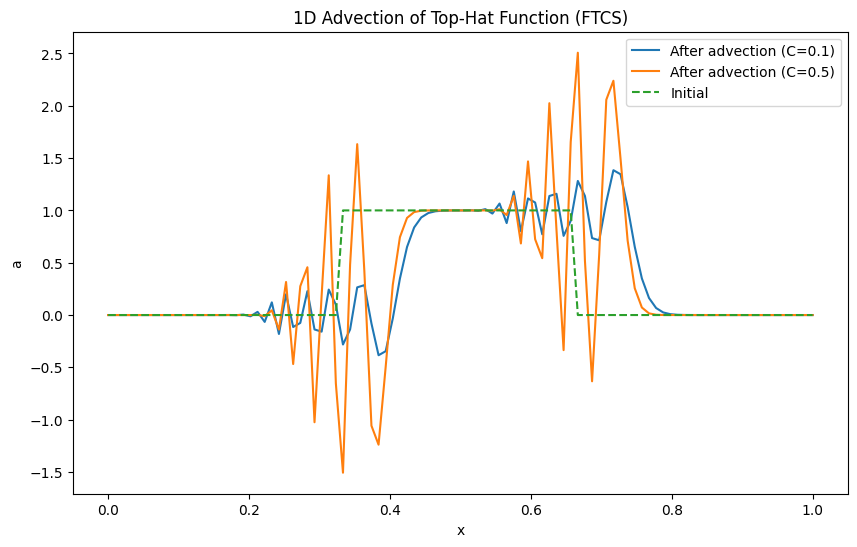

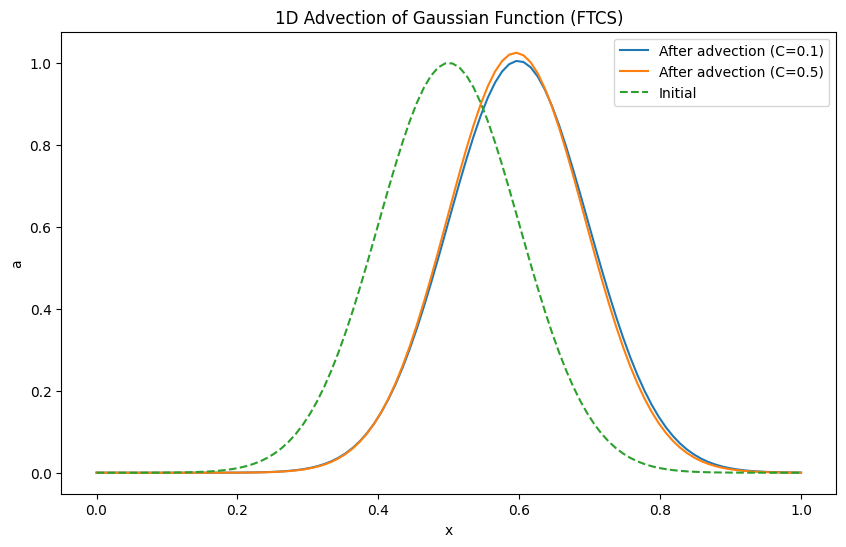

In [39]:
def FTCS(a):
    a_new = np.zeros_like(a)
    for i in range(len(a)):
            a_new[i] = a[i] - 0.5*C*(a[(i+1) % nx] - a[i-1]) # periodic BC: a[-1] = a[nx-1]
    return a_new

T = 0.1 # number of time periods since T = 1/u = 1
for IC, label in zip([x0_top_hat, x0_gaussian], ['Top-Hat', 'Gaussian']):
    plt.figure(figsize=(10, 6))
    for C in [0.1, 0.5]: # test different Courant numbers
        dt = C*dx/u # time step
        a = IC.copy()
        for n in range(int(T/dt)):
            a = FTCS(a)

        plt.plot(x, a, label=f'After advection (C={C})')    

    plt.plot(x, IC, '--', label='Initial')
    plt.xlabel('x')
    plt.ylabel('a')
    plt.title(f'1D Advection of {label} Function (FTCS)')
    plt.legend()
    plt.show()

# Exercise 4.7 (a) first-order finite-difference implicit method for linear advection

We are solving a_t + u a_x = 0

The upwinded implicit update appears as: 

$$-C a^{n+1}_{i-1} + (1 - C) a^{n+1}_{i} = a^n_i $$

 where C is the CFL number

 We use a periodic grid with N points, 0, ..., N-1, with the data
 located at those points.  This means that since 0 and N-1 are on
 the boundary, they are the same point.  Therefore, we only need
 to update points 1, ..., N-1

 No ghost points are used here.

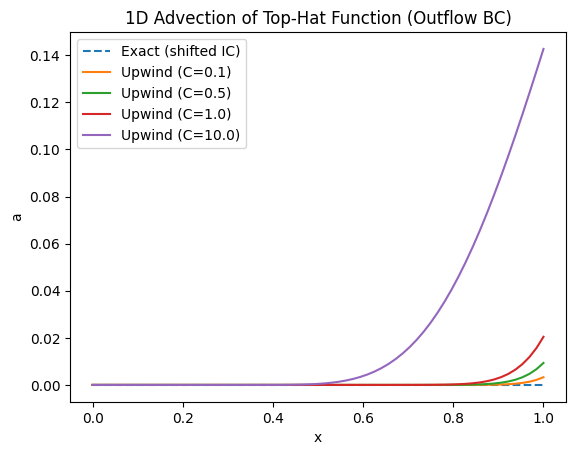

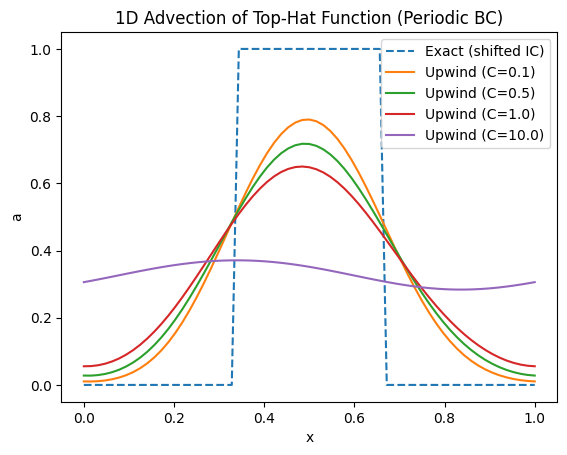

In [49]:
import numpy as np
import matplotlib.pyplot as plt


def top_hat_IC(x):
    if 0 <= x < 1/3:
        return 0.0
    elif 1/3 <= x < 2/3:
        return 1.0
    else:
        return 0.0

def periodic_BC(a):
    a[0] = a[-1] # periodic BC: a[0] = a[nx-1]
    return a

def outflow_BC(a):
    a[-1] = a[-2] # outflow BC: a[nx-1] = a[nx-2]
    return a

def evolve_upwind(nx, dx, C, u, tmax, periodic_BC, outflow_BC):
    
    #define dt based on the CFL condition
    dt = C*dx/u
    x = np.arange(nx) * dx # spatial grid

    a0_top_hat = np.array([top_hat_IC(xi) for xi in x]) # initial condition vector (top-hat function)

    #solution vector
    a = np.zeros((nx))
    a[:] = a0_top_hat[:]

    #periodic BC: a[0] = a[nx-1]
    if periodic_BC is not None:
        periodic_BC(a)
    
    #outflow BC: a[nx-1] = a[nx-2]
    if outflow_BC is not None:
        outflow_BC(a)
    
    # matrix A for the upwind scheme
    A = np.zeros((nx-1, nx-1))
    t = 0
    while t < tmax:
        #create the matrix A for the upwind scheme
        for i in range(nx-1):
            A[i, i] = 1 + C
            A[i, i-1] = -C
        
        
        # RHS vector -- this holds all entries except for a[0]
        b = a[1:nx].copy() # this is a[1], a[2], ..., a[nx-1]
        
        if outflow_BC is not None:
            A[0,-1] = 0.0 # modify the first row of A for outflow BC
        
        # if t == 0:
        #     print("Matrix A for the upwind scheme:")
        #     print(A)
        
        #solve the system
        anew = np.linalg.solve(A, b)
        
        a[1:nx] = anew[:] # update a[1], a[2], ..., a[nx-1]
        
        if periodic_BC is not None:
            periodic_BC(a)

        t += dt
    return a


u = 1.0 # advection speed
nx = 65 # number of spatial points
xmin = 0.0
xmax = 1.0
dx = (xmax - xmin) / (nx - 1) # spatial step
x = np.arange(nx) * dx # spatial grid

#time info
CFL = [0.1, 0.5, 1.0, 10.0] # Courant number
T = 1 # number of time periods since T = 1/u = 1

a0_top_hat = np.array([top_hat_IC(xi) for xi in x]) # initial condition vector (top-hat function)


for n, C in enumerate(CFL):
    a_final = evolve_upwind(nx, dx, C, u, T, periodic_BC=None, outflow_BC=outflow_BC)
    if n == 0:
        a0_top_hat_outflow = np.zeros_like(x)
        for i in range(nx):
            xi_shifted = (x[i] - u*T) # shift x[i] by u*T
            a0_top_hat_outflow[i] = top_hat_IC(xi_shifted) # compute the exact solution at time T by evaluating the initial condition at the shifted position
        # plot exact solution (initial condition shifted by u*T)
        plt.plot(x, a0_top_hat_outflow, label='Exact (shifted IC)', linestyle='--')
    
    plt.plot(x, a_final, label=f'Upwind (C={C})')
    plt.title(f'1D Advection of Top-Hat Function (Outflow BC)')
    plt.xlabel('x')
    plt.ylabel('a')
    plt.legend()
plt.show()
for n, C in enumerate(CFL):
    a_final = evolve_upwind(nx, dx, C, u, T, periodic_BC=periodic_BC, outflow_BC=None)
    if n == 0:
        # plot exact solution (initial condition shifted by u*T)
        plt.plot(x, a0_top_hat, label='Exact (shifted IC)', linestyle='--')
    
    plt.plot(x, a_final, label=f'Upwind (C={C})')
    plt.title(f'1D Advection of Top-Hat Function (Periodic BC)')
    plt.xlabel('x')
    plt.ylabel('a')
    plt.legend()
plt.show()